<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/SRCNN/EDSR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import tensorflow as tf
import os
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

AUTOTUNE = tf.data.AUTOTUNE

In [93]:
!pip install pillow
from PIL import Image

In [95]:
def decode_image_safe(image_bytes, min_size=2):
    try:
        image = tf.image.decode_png(image_bytes, channels=3)
        shape = tf.shape(image)
        if shape[0] < min_size or shape[1] < min_size:
            return tf.zeros([min_size, min_size, 3], dtype=tf.float32)
        return tf.image.convert_image_dtype(image, tf.float32)
    except:
        return tf.zeros([min_size, min_size, 3], dtype=tf.float32)

In [96]:
def load_image_pair(lr_path, hr_path):
    try:
        lr_bytes = tf.io.read_file(lr_path)
        hr_bytes = tf.io.read_file(hr_path)
        lr = decode_image_safe(lr_bytes, min_size=16)
        hr = decode_image_safe(hr_bytes, min_size=64)

        if tf.reduce_any(tf.shape(lr)[:2] < 16) or tf.reduce_any(tf.shape(hr)[:2] < 64):
            return None, None

        lr = lr * 255.0
        hr = hr * 255.0

        return lr, hr
    except:
        return None, None

In [97]:
def safe_augment(lr_img, hr_img):
    if lr_img is None or hr_img is None:
        return lr_img, hr_img

    try:
        lr_shape = tf.shape(lr_img)
        hr_shape = tf.shape(hr_img)

        if lr_shape[0] == 0 or lr_shape[1] == 0 or hr_shape[0] == 0 or hr_shape[1] == 0:
            return lr_img, hr_img

        if tf.random.uniform(()) > 0.5:
            lr_img = tf.image.flip_left_right(lr_img)
            hr_img = tf.image.flip_left_right(hr_img)

        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        lr_img = tf.image.rot90(lr_img, k)
        hr_img = tf.image.rot90(hr_img, k)

        return lr_img, hr_img
    except:
        return lr_img, hr_img

In [98]:
def random_crop(lr_img, hr_img, hr_crop_size=128, scale=4):
    if lr_img is None or hr_img is None:
        return None, None

    try:
        lr_crop_size = hr_crop_size // scale
        lr_shape = tf.shape(lr_img)[:2]
        hr_shape = tf.shape(hr_img)[:2]

        if lr_shape[0] < lr_crop_size or lr_shape[1] < lr_crop_size or \
           hr_shape[0] < hr_crop_size or hr_shape[1] < hr_crop_size:
            return tf.image.resize(lr_img, [lr_crop_size, lr_crop_size]), \
                   tf.image.resize(hr_img, [hr_crop_size, hr_crop_size])

        lr_x = tf.random.uniform((), 0, lr_shape[1] - lr_crop_size + 1, dtype=tf.int32)
        lr_y = tf.random.uniform((), 0, lr_shape[0] - lr_crop_size + 1, dtype=tf.int32)
        hr_x = lr_x * scale
        hr_y = lr_y * scale

        lr_crop = lr_img[lr_y:lr_y+lr_crop_size, lr_x:lr_x+lr_crop_size, :]
        hr_crop = hr_img[hr_y:hr_y+hr_crop_size, hr_x:hr_x+hr_crop_size, :]

        return lr_crop, hr_crop
    except:
        return tf.image.resize(lr_img, [lr_crop_size, lr_crop_size]), \
               tf.image.resize(hr_img, [hr_crop_size, hr_crop_size])

In [99]:
def preprocess(lr_path, hr_path, training=True):
    lr, hr = load_image_pair(lr_path, hr_path)

    if lr is None or hr is None:
        return tf.zeros([16, 16, 3], dtype=tf.float32), tf.zeros([64, 64, 3], dtype=tf.float32)

    if training:
        lr, hr = random_crop(lr, hr)
        lr, hr = safe_augment(lr, hr)

    tf.debugging.assert_greater_equal(lr, 0.0)
    tf.debugging.assert_less_equal(lr, 255.0)
    tf.debugging.assert_greater_equal(hr, 0.0)
    tf.debugging.assert_less_equal(hr, 255.0)

    return lr, hr

In [100]:
def build_dataset(lr_dir, hr_dir, training=True, batch_size=8):
    lr_paths = sorted([os.path.join(lr_dir, f) for f in os.listdir(lr_dir)])
    hr_paths = sorted([os.path.join(hr_dir, f) for f in os.listdir(hr_dir)])

    ds = tf.data.Dataset.from_tensor_slices((lr_paths, hr_paths))
    ds = ds.map(lambda lr, hr: preprocess(lr, hr, training), num_parallel_calls=AUTOTUNE)

    ds = ds.filter(lambda lr, hr: tf.reduce_all(tf.shape(lr) > 0) and tf.reduce_all(tf.shape(hr) > 0))

    if training:
        ds = ds.shuffle(1000)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [102]:
class EDSRModel(keras.Model):
    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.compiled_loss(y, y_pred, regularization_losses=self.losses)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.compiled_metrics.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

    def predict_step(self, x):
        # Giriş tensörünün boyutlarını düzelt
        if len(x.shape) == 4:  # Eğer giriş (batch, height, width, channels) şeklindeyse
            x = tf.squeeze(x, axis=0)  # Batch boyutunu kaldır
        x = tf.cast(x, tf.float32)
        sr = self(tf.expand_dims(x, 0), training=False)
        sr = tf.clip_by_value(sr, 0, 255)
        sr = tf.round(sr)
        sr = tf.squeeze(tf.cast(sr, tf.uint8), axis=0)
        return sr

def ResBlock(inputs):
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(64, 3, padding="same")(x)
    return layers.Add()([inputs, x])

def Upsampling(inputs, scale=4):
    x = inputs
    for _ in range(int(scale / 2)):
        x = layers.Conv2D(256, 3, padding="same")(x)
        x = layers.Lambda(lambda x: tf.nn.depth_to_space(x, 2))(x)
    return x

def make_model(num_filters=64, num_res_blocks=16, scale=4):
    inp = layers.Input(shape=(None, None, 3))
    x = layers.Rescaling(1./255)(inp)
    res = x = layers.Conv2D(num_filters, 3, padding="same")(x)

    for _ in range(num_res_blocks):
        res = ResBlock(res)

    x = layers.Conv2D(num_filters, 3, padding="same")(res)
    x = layers.Add()([x, res])
    x = Upsampling(x, scale)
    x = layers.Conv2D(3, 3, padding="same")(x)
    out = layers.Rescaling(255)(x)

    return EDSRModel(inp, out)

In [104]:
def average_psnr(model, val_ds):
    psnrs = []
    for lr, hr in val_ds:
        sr = model.predict(lr, verbose=0)
        sr = tf.clip_by_value(sr, 0, 255)
        sr = tf.cast(sr, tf.uint8)
        hr = tf.cast(hr, tf.uint8)
        psnr = tf.image.psnr(hr, sr, max_val=255.0)
        psnr_value = psnr.numpy()
        psnr_value = psnr_value[~np.isinf(psnr_value)]
        if len(psnr_value) > 0:
            psnrs.extend(psnr_value)
    return sum(psnrs) / len(psnrs) if psnrs else 0

In [105]:
def save_image(tensor, path):
    arr = tf.clip_by_value(tensor, 0, 255)
    arr = tf.cast(arr, tf.uint8).numpy()
    img = Image.fromarray(arr)
    img.save(path)

In [106]:
train_lr = "/content/drive/MyDrive/2209/dataset_srcnn/LR/train"
train_hr = "/content/drive/MyDrive/2209/dataset_srcnn/HR/train"
val_lr = "/content/drive/MyDrive/2209/dataset_srcnn/LR/val"
val_hr = "/content/drive/MyDrive/2209/dataset_srcnn/HR/val"

train_ds = build_dataset(train_lr, train_hr, training=True, batch_size=8)
val_ds = build_dataset(val_lr, val_hr, training=False, batch_size=1)

model = make_model(scale=4)
lr_schedule = keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[5000], values=[1e-4, 5e-5]
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="mae",
    metrics=[tf.keras.metrics.MeanSquaredError()]
)

os.makedirs("outputs", exist_ok=True)
checkpoint_path = "outputs/best_model.h5"
log_path = "outputs/training_log.csv"
best_psnr = 0

with open(log_path, "w") as f:
    f.write("epoch,psnr\n")

for epoch in range(1, 101):
    print(f"\n--- Epoch {epoch} ---")
    model.fit(train_ds, epochs=1, steps_per_epoch=200, validation_data=val_ds, verbose=1)

    psnr = average_psnr(model, val_ds)
    print(f"Validation PSNR: {psnr:.2f} dB")

    with open(log_path, "a") as f:
        f.write(f"{epoch},{psnr:.4f}\n")

    if psnr > best_psnr:
        best_psnr = psnr
        model.save_weights(checkpoint_path.replace(".h5", ".weights.h5"))
        print("✅ Yeni en iyi model kaydedildi.")

    out_dir = f"outputs/epoch_{epoch}"
    os.makedirs(out_dir, exist_ok=True)
    for i, (lr, _) in enumerate(val_ds.take(3)):
        pred = model.predict_step(lr[0])
        save_image(pred, f"{out_dir}/pred_{i+1}.png")
        save_image(lr[0], f"{out_dir}/lr_{i+1}.png")


--- Epoch 1 ---


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:667: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:642: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


133/200 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - mean_squared_error: 0.0000e+00 - loss: 0.0000e+00

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - mean_squared_error: 0.0000e+00 - loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_mean_squared_error: 0.0000e+00
Validation PSNR: 0.00 dB

--- Epoch 2 ---
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - mean_squared_error: 0.0000e+00 - loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_mean_squared_error: 0.0000e+00
Validation PSNR: 0.00 dB

--- Epoch 3 ---
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - mean_squared_error: 0.0000e+00 - loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_mean_squared_error: 0.0000e+00
Validation PSNR: 0.00 dB

--- Epoch 4 ---
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - mean_squared_error: 0.0000e+00 - loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_mean_squared_error: 0.0000e+00


KeyboardInterrupt: 

LR max: 0.0 min: 0.0
HR max: 0.0 min: 0.0


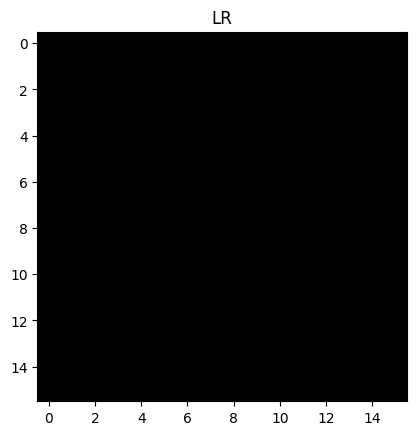

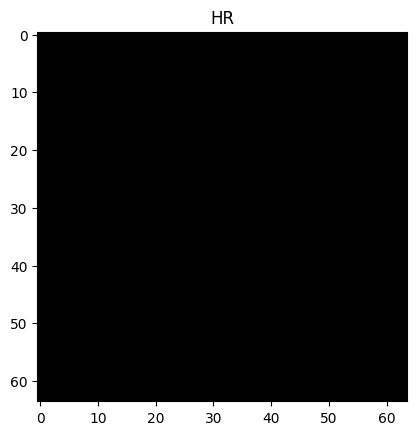

In [107]:
for lr, hr in train_ds.take(1):
    print("LR max:", tf.reduce_max(lr).numpy(), "min:", tf.reduce_min(lr).numpy())
    print("HR max:", tf.reduce_max(hr).numpy(), "min:", tf.reduce_min(hr).numpy())
    plt.imshow(tf.cast(lr[0], tf.uint8)); plt.title("LR"); plt.show()
    plt.imshow(tf.cast(hr[0], tf.uint8)); plt.title("HR"); plt.show()

In [109]:
import numpy as np
img = Image.open("/content/drive/MyDrive/2209/dataset_srcnn/LR/test/M0207_img000219.jpg")
img_arr = np.array(img)

print("Image shape:", img_arr.shape)
print("Max pixel value:", img_arr.max())
print("Min pixel value:", img_arr.min())

Image shape: (270, 512, 3)
Max pixel value: 255
Min pixel value: 0
